# Qualitative Evaluation

## Showing one image with its prediction and references

In [2]:
import json
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image


def load_results(json_path: str) -> list:
    with open(json_path) as f:
        data = json.load(f)
    return data["results"]


def show_result(results: list, idx: int, data_dir: str, split: str = "val"):
    r = results[idx]
    
    img_path = Path(data_dir) / split / r["file_name"]
    image = Image.open(img_path).convert("RGB")
    
    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.axis("off")
    plt.show()

    print(f"FILE: {r['file_name']}")
    print(f"PREDICTION: {r['prediction']}")
    print()
    for i, ref in enumerate(r["references"]):
        print(f"REF {i+1}: {ref}")


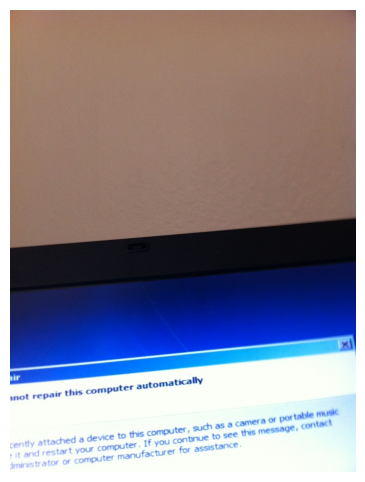

FILE: VizWiz_val_00000000.jpg
PREDICTION: a laptop computer sitting on top of a desk

REF 1: A computer screen shows a repair prompt on the screen.
REF 2: a computer screen with a repair automatically pop up
REF 3: partial computer screen showing the need of repairs
REF 4: Part of a computer monitor showing a computer repair message.
REF 5: The top of a laptop with a blue background and dark blue text.


In [3]:
results = load_results("../results/task1/vit-gpt2-pretrained.json")
DATA_DIR = "../data/"

show_result(results, idx=0, data_dir=DATA_DIR)

## Comparing metrics across different models

In [ ]:
import pandas as pd

def load_results(json_path: str) -> dict:
    with open(json_path) as f:
        return json.load(f)  

def compare_metrics(model_results: dict):
    rows = []
    for name, data in model_results.items():
        rows.append({
            "model": name,
            **data["metrics"]
        })
    return pd.DataFrame(rows).set_index("model")

In [7]:
df = compare_metrics({
    "vit-gpt2": load_results("../results/task1/vit-gpt2-pretrained.json"),
    "blip-base": load_results("../results/task1/blip-base-pretrained.json"),
    "blip-large": load_results("../results/task1/blip-large-pretrained.json"),
})
print(df)

               bleu1     bleu2    rougeL    meteor
model                                             
vit-gpt2    0.514626  0.319896  0.365729  0.279635
blip-base   0.557597  0.381486  0.413974  0.328024
blip-large  0.516263  0.347545  0.393655  0.367401
